# MLP with hyperparameter Tuning [(medium-article)](https://medium.com/@vijaikdasari/multilayer-perceptron-and-its-hyperparameter-tuning-deedfbca2d1b)

- Grid search --> all combinations, smaller networks + limited hyperparameter ranges
- Random search --> random combinations, high-dimensional hyperparameter spaces
- Bayesian optimization --> probabilistic model that balances exploration (trying new hyperparameter combinations) and exploitation (refining around known good values), complex model + large datasets
- Automated Machine Learning (AutoML) Tools --> flexible hyperparameter search configurations, Keras Tuner / Optuna

## Import

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import src.utils as utils
import src.nn_core as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential      # type: ignore
from tensorflow.keras.layers import Dense, Dropout  # type: ignore
from tensorflow.keras.optimizers import Adam        # type: ignore

## Upload

In [3]:
df = utils.load_data()
display(df.head())

Dataset caricato: 65 anni, 28 variabili.


,Year,Agricultural land (% of land area),Agricultural land (sq. km),Agricultural raw materials exports (% of merchandise exports),Agricultural raw materials imports (% of merchandise imports),"Agriculture, forestry, and fishing, value added (% of GDP)","Agriculture, forestry, and fishing, value added (current US$)","Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)",Arable land (% of land area),Arable land (hectares per person),...,Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land under cereal production (hectares),Livestock production index (2014-2016 = 100),Permanent cropland (% of land area),Rural population,Rural population (% of total population),Rural population growth (annual %)
0,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20400656.0,40.639,NaN
1,1961,70.324028,206830.0,NaN,NaN,NaN,NaN,NaN,43.731937,0.254510,...,67.795055,85.93,NaN,NaN,6387203.0,70.91,9.336643,20287312.0,40.144,-0.557139
2,1962,70.218626,206520.0,2.563660,16.566057,NaN,NaN,NaN,43.504131,0.251477,...,69.362485,86.90,NaN,NaN,6485855.0,72.59,9.435245,20171158.0,39.645,-0.574190
3,1963,69.735813,205100.0,2.651714,14.571604,NaN,NaN,NaN,43.092720,0.247288,...,68.764636,86.37,NaN,NaN,6299467.0,65.95,9.319642,20063620.0,39.147,-0.534554
4,1964,69.572609,204620.0,2.792923,15.115329,NaN,NaN,NaN,42.834314,0.243791,...,74.639625,90.28,NaN,NaN,6244904.0,69.57,9.438645,19972523.0,38.650,-0.455075


## Splitting in train, validation and test set

l'orizzonte di test è adattivo in base alla disponibilità dei dati storici di ciascun indicatore

============================== AGRICULTURAL LAND (% OF LAND AREA) ==============================
Train: 1961-2003 (43 obs)
Val:   2004-2013 (10 obs)
Test:  2014-2022 (9 obs)


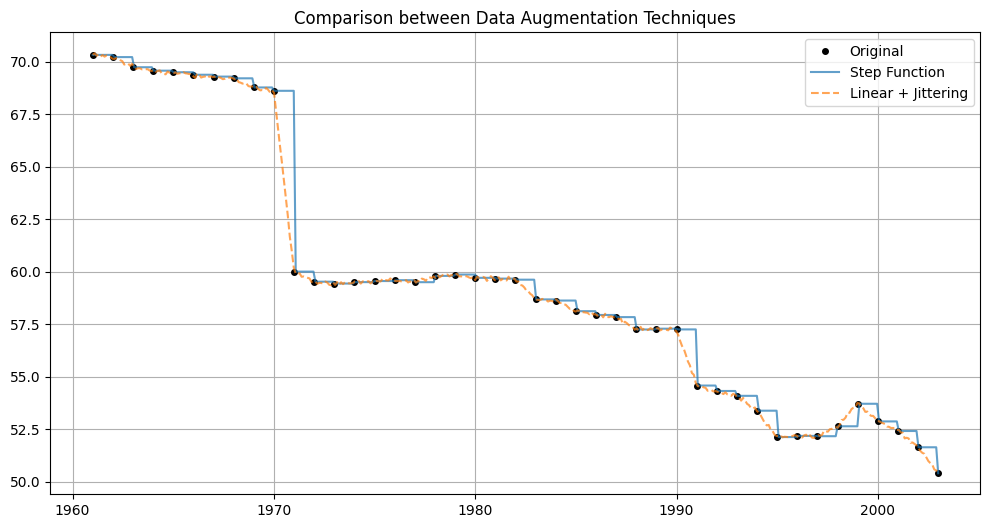

============================== AGRICULTURE, FORESTRY, AND FISHING, VALUE ADDED (% OF GDP) ==============================
Train: 1990-2013 (24 obs)
Val:   2014-2019 (6 obs)
Test:  2020-2024 (5 obs)


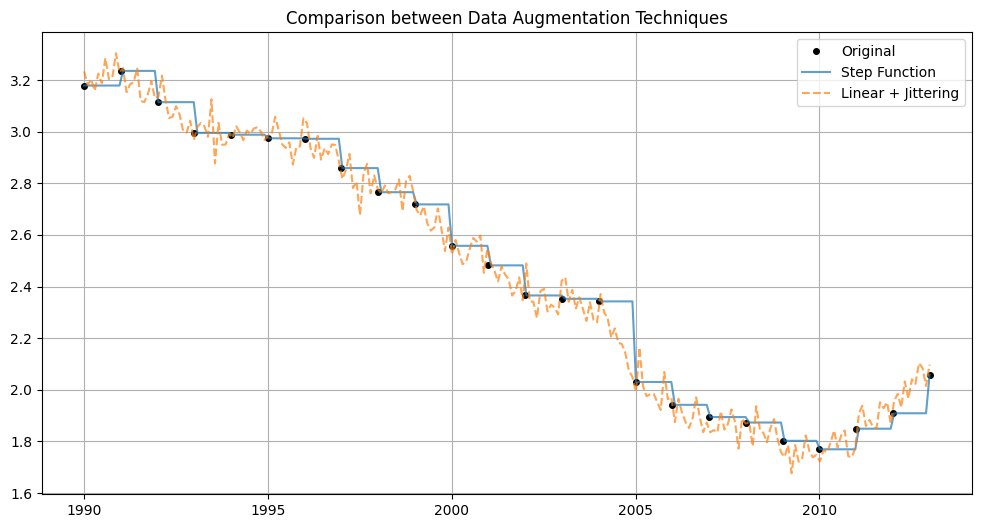

============================== CEREAL YIELD (KG PER HECTARE) ==============================
Train: 1961-2003 (43 obs)
Val:   2004-2013 (10 obs)
Test:  2014-2022 (9 obs)


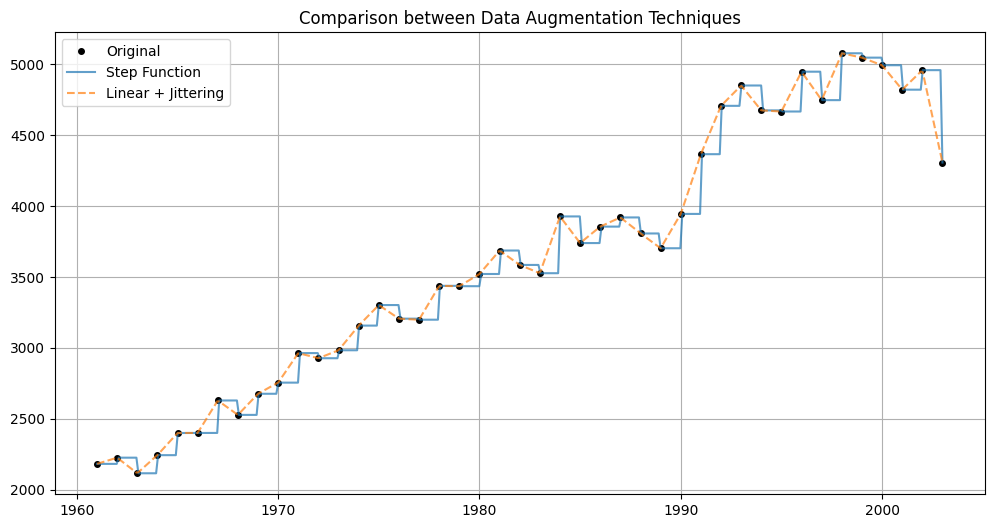

In [6]:
# indicators = [i for i in df.columns if i != 'Year']

# dizionario per salvare in memoria i subset originali e i train aumentati con step e linear
orig_aug_subsets = {}

# per ora lo faccio solo su sti tre per capire se funziona
indicators = ['Agricultural land (% of land area)',
            'Agriculture, forestry, and fishing, value added (% of GDP)',
            'Cereal yield (kg per hectare)']
for indicator in indicators:
    print('='*30, indicator.upper(), '='*30)
    df_temp = df[['Year', indicator]].dropna().copy()
    df_temp.columns = ['Year', 'Value']
    train_orig, val_orig, test_orig = nn.split_time_series(df_temp)    # splitto la time serie ORIGINALE
    
    # faccio augmentation SOLO sul train set: aumento sia anni che valori
    x_train_vals = train_orig['Year']
    y_train_vals = train_orig['Value']
    
    df_step = nn.augment_step_function(x_train_vals, y_train_vals, scale_factor=10)
    df_jitter = nn.augment_linear_with_jitter(x_train_vals, y_train_vals, scale_factor=10, noise_level=0.05)
    nn.plot_augmented(df_step, df_jitter, x_train_vals, y_train_vals)
    orig_aug_subsets[indicator] = {
        'orig_train': train_orig,
        'step_aug_df': df_step,
        'jitter_aug_df': df_jitter,
        'orig_val': val_orig,
        'orig_test': test_orig
    }

In [ ]:
total_scaled_data = {} 
total_scalers = {}

for indicator in indicators:
    scaled_subsets, scalers = nn.scale_datasets(orig_aug_subsets[indicator])
    total_scaled_data[indicator] = scaled_subsets
    total_scalers[indicator] = scalers

In [ ]:
X = df.data
y = df.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import optuna
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import utils

# Funzione obiettivo per Optuna
def objective(trial, series_data):
    # 1. Suggerimento Iperparametri (Optuna sceglie valori nel range)
    n_layers = trial.suggest_int('n_layers', 1, 3)
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)
    n_input_steps = trial.suggest_int('n_input_steps', 3, 12)
    
    # 2. Creazione Dataset per questa prova (Train/Val split)
    # Nota: series_data qui è solo la parte di Train+Validation (NO TEST)
    # Dividiamo internamente per valutare questa configurazione
    split_idx = int(len(series_data) * 0.8) 
    train_subset = series_data[:split_idx]
    val_subset = series_data[split_idx:]
    
    # Crea sequenze X, y (usando la tua funzione utils)
    X_train, y_train = utils.create_sequences(train_subset, n_input_steps)
    X_val, y_val = utils.create_sequences(val_subset, n_input_steps)
    
    # Se le sequenze sono vuote (troppi pochi dati), prune trial
    if len(X_train) == 0 or len(X_val) == 0:
        raise optuna.TrialPruned()

    # 3. Costruzione Modello MLP
    model = Sequential()
    model.add(Dense(trial.suggest_int('units_L1', 16, 128), 
                    activation='relu', input_dim=n_input_steps))
    
    for i in range(n_layers - 1):
        model.add(Dense(trial.suggest_int(f'units_L{i+2}', 16, 64), activation='relu'))
        model.add(Dropout(0.2)) # Hardcoded o tunabile
        
    model.add(Dense(1)) # Output layer
    
    # 4. Compile & Fit
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    
    # Allenamento veloce (pochi epochs per il tuning)
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), 
                        epochs=50, batch_size=16, verbose=0)
    
    # 5. Ritorna la loss di validazione (l'obiettivo è minimizzarla)
    val_loss = np.min(history.history['val_loss'])
    return val_loss

# --- MAIN LOOP ---
def run_framework():
    indicators = ["GDP", "Population", ...] # La tua lista
    
    for indicator in indicators:
        print(f"Processing {indicator}...")
        
        # A. Carica dati
        df = utils.load_data()
        series = df[indicator].dropna().values
        # Scaling qui (fit su train, transform su tutto)
        
        # B. Split Train_Val (per tuning) vs Test (per tesi)
        test_size = 10 # Ultimi 10 anni
        train_val_data = series[:-test_size]
        test_data_raw = series[-test_size:] # Serve il contesto per creare X_test
        
        # C. Esegui Tuning (Optuna)
        study = optuna.create_study(direction='minimize')
        # Passiamo i dati tramite lambda per fissare l'argomento
        study.optimize(lambda trial: objective(trial, train_val_data), n_trials=20)
        
        best_params = study.best_params
        print(f"Best params for {indicator}: {best_params}")
        
        # D. Training Finale (Modello Vincitore)
        # Ora usiamo n_input_steps vincitore per creare il dataset finale
        n_steps = best_params['n_input_steps']
        
        # Ricreiamo dataset completo (Train + Val) per allenare al massimo
        X_final_train, y_final_train = utils.create_sequences(train_val_data, n_steps)
        
        # Costruisci modello con best_params...
        final_model = build_model_from_params(best_params) 
        final_model.fit(X_final_train, y_final_train, epochs=100, verbose=0)
        
        # E. Predizione sul Test Set
        # (Attenzione: per predire T serve T-n_steps, prendili dalla fine di train_val_data)
        # ... logica di predizione ...
        
        # F. Metriche e Salvataggio
        metrics = utils.evaluate_forecast(y_test_real, predictions)
        
        # Aggiungi i parametri al salvataggio!
        metrics.update(best_params) # Unisce i dizionari
        
        utils.save_metrics("MLP_Optuna", indicator, metrics)

for ogni_indicatore in 28_indicatori:
    # 1. Ottimizza iperparametri specifici per questa serie
    best_params = hyperparameter_tuning(indicatore_data)
    
    # 2. Training del modello con parametri ottimizzati
    model = train_MLP(data, best_params)
    
    # 3. Calcola metriche
    metrics = calculate_all_metrics(test, predictions)
    
    # 4. Salva metriche con iperparametri
    append_metrics_to_excel(indicatore, 'MLP', metrics)
